# Imports

In [1]:
from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import os  # add directory containing the input data (opacity, abundance and stellar specs files)
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

import h5py

import numpy as np
import matplotlib.pyplot as plt

import starships.retrieval_utils as ru

# Quicklook at one of the files

In [2]:
# Path to the walker files
walker_path = Path('/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/')

In [3]:
ls -t1 $walker_path | head -15  # list the walker files

walker_steps_greenhouse-gases_v2_8.h5
walker_steps_greenhouse-gases_v2_6.h5
walker_steps_greenhouse-gases_v2_7.h5
walker_steps_greenhouse-gases_v2_10.h5
walker_steps_greenhouse-gases_v2_4.h5
walker_steps_greenhouse-gases_v2_1.h5
walker_steps_greenhouse-gases_v2_9.h5
walker_steps_greenhouse-gases_v2_3.h5
walker_steps_greenhouse-gases_v2_5.h5
walker_steps_greenhouse-gases_v2_2.h5
walker_steps_greenhouse-gases.h5
walker_steps_greenhouse-gases_combined.h5
walker_steps_greenhouse-gases_4.h5
walker_steps_greenhouse-gases_5.h5
walker_steps_greenhouse-gases_6.h5


In [4]:
# Choose which walker files to look at and merge (copy-paste one of them)
walkers_to_merge = 'walker_steps_greenhouse-gases_v2_8.h5'

INFO:starships.retrieval_utils:Steps in walkers file are all completed


0: Maximum=-8.446080671666628, Error=[-3.42773854  4.27550641], HDI(68.00%)=[-11.87381922  -4.17057426]
1: Maximum=-10.538976824007907, Error=[ 2.01534635 10.41508367], HDI(68.00%)=[-8.52363048 -0.12389315]
2: Maximum=-10.109222994789246, Error=[-1.8904226   5.70232056], HDI(68.00%)=[-11.9996456   -4.40690243]
3: Maximum=531.9294877767734, Error=[-301.53390713   67.74794849], HDI(68.00%)=[230.39558064 599.67743627]
4: Maximum=81.41998309045415, Error=[-37.12101212  17.79023559], HDI(68.00%)=[44.29897097 99.21021868]
5: Maximum=4.930205826779745, Error=[-9.55652414  2.15551439], HDI(68.00%)=[-4.62631832  7.08572022]


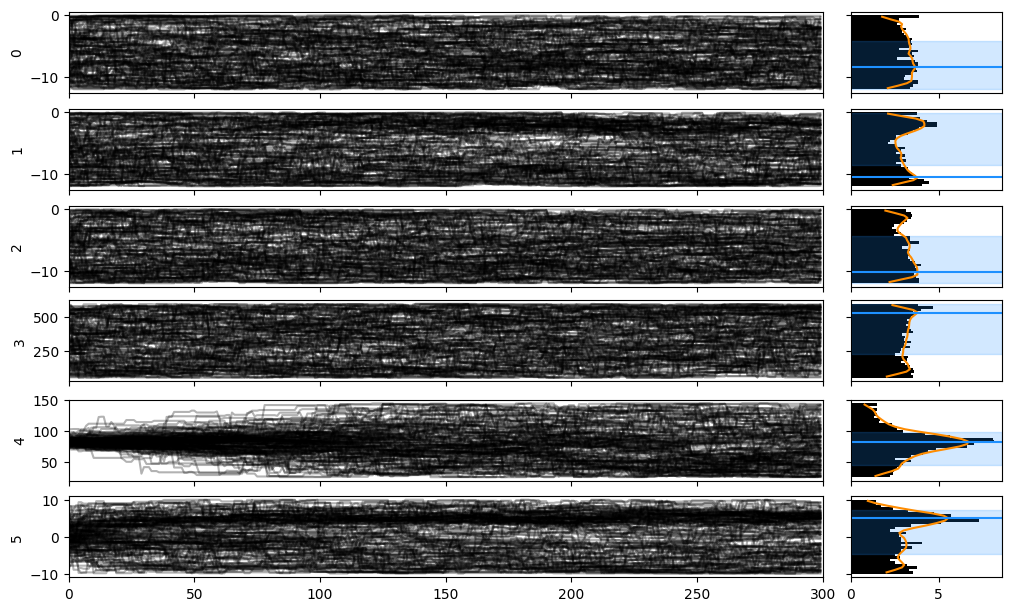

In [5]:
walker_file = Path(walkers_to_merge)
chains = ru.read_walkers_file(walker_path / walker_file, discard=0)
maxs, errors = ru.find_dist_maxs(chains, bin_size=6)

# Merge multiple walker files

In [6]:
# Get a list of walker files from the same run as walkers_to_merge
walker_file_list = list(walker_path.glob(walkers_to_merge[:-4] + '*.h5'))

# Name for combined file
combined_file_out = Path(walkers_to_merge[:-4] + 'combined.h5')

## Get number of steps (minimum among all files)

In [7]:
nsteps = 300

for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file, 'r') as f:
        dset = f['mcmc']
        print(walker_file, 'n_steps:', dset.attrs['iteration'])
        nsteps = np.min([nsteps, dset.attrs['iteration']])

nsteps = int(nsteps)
print('nsteps:', nsteps)

/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_6.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_7.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_10.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_5.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_4.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_1.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_3.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_2.h5 n_steps: 300
/home/mathisb/scratch/HRS_retrievals/walker_steps/TRAPPIST-1b/walker_steps_greenhouse-gases_v2_

## Show best walkers from all files

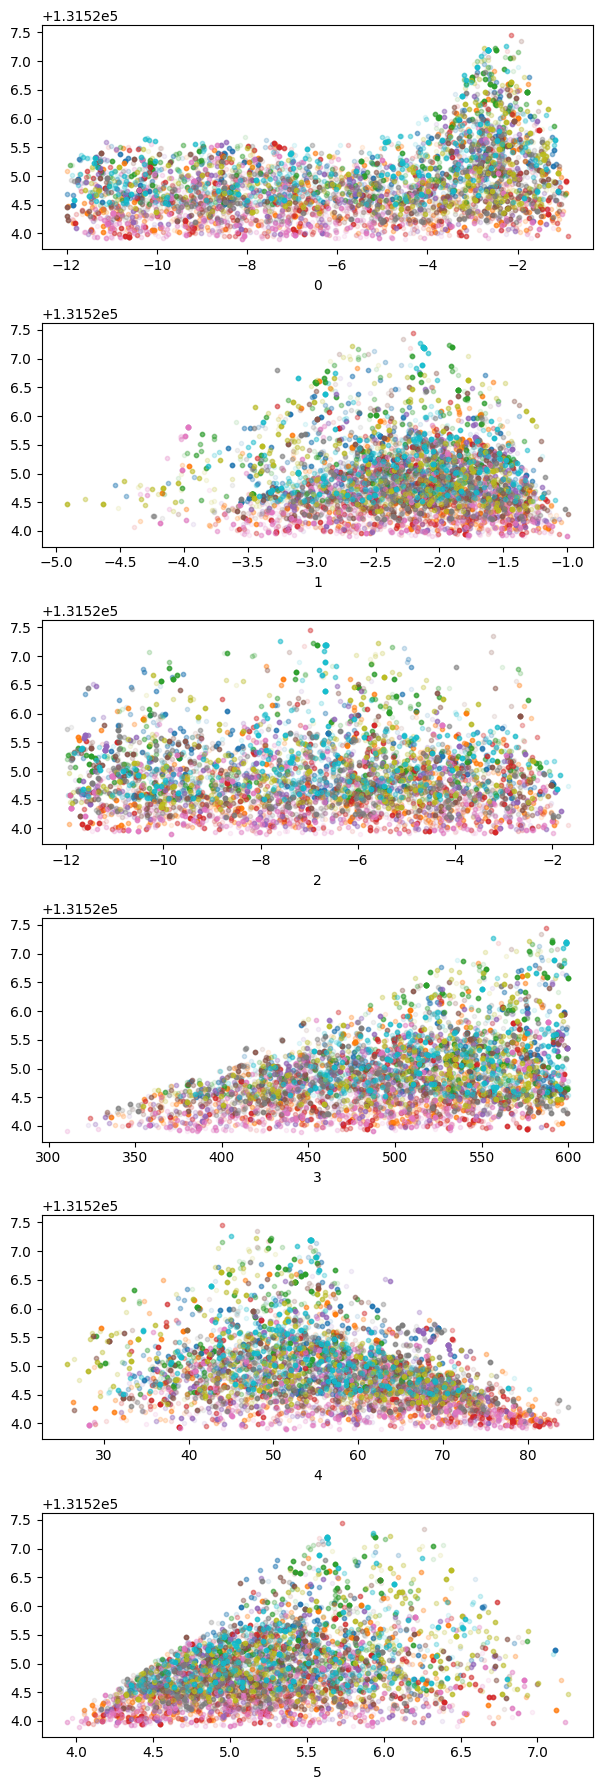

In [8]:
n_best = 2000

fig =None

for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file) as f:
        dset = f['mcmc']
        ord_logl = dset['log_prob'][-nsteps:].reshape(-1)
        ord_pos = dset['chain'][-nsteps:]
        n_param = ord_pos.shape[-1]
        ord_pos = ord_pos.reshape((-1, n_param))
        idx_sort = np.argsort(ord_logl)
        ord_pos = ord_pos[idx_sort]
        ord_logl = ord_logl[idx_sort]
        
        if fig is None:
            fig, ax = plt.subplots(n_param, 1, figsize=(6, 3*n_param))
        
        for i_param, ax_i in enumerate(ax):
            ax_i.plot(ord_pos[-n_best:,i_param], ord_logl[-n_best:], ".", alpha=0.1)
#             ax_i.set_ylim(*ylim)
            ax_i.set_xlabel(i_param)
plt.tight_layout()
        

## Combine the different files

In [9]:
combined = {key: [] for key in ['accepted', 'chain', 'log_prob']}
for walker_file in walker_file_list:
    with h5py.File(walker_path / walker_file) as f:
        dset = f['mcmc']
        last_step = dset.attrs['iteration']
        for key in ['chain', 'log_prob']:
            combined[key].append(dset[key][last_step - nsteps: last_step])
        combined['accepted'].append(dset['accepted'][...])

combined['chain'] = np.concatenate(combined['chain'], axis=1)
combined['log_prob'] = np.concatenate(combined['log_prob'], axis=1)
combined['accepted'] = np.concatenate(combined['accepted'])

In [21]:
print(combined_file_out)
combined['chain'].shape, combined['log_prob'].shape

walker_steps_greenhouse-gases_v2_combined.h5


((300, 1600, 6), (300, 1600))

## And save

In [11]:
# !rm $walker_path/$combined_file_out

In [12]:
with h5py.File(walker_path / combined_file_out, 'a') as f:
    grp = f.create_group("mcmc")
    for key, val in combined.items():
        grp[key] = val
        
    grp.attrs['has_blob'] = False
    for key, val in zip(['iteration', 'nwalkers', 'ndim'], combined['chain'].shape):
        grp.attrs[key] = val
    

## Read the saved file to check if all went well

In [13]:
with h5py.File(walker_path / combined_file_out) as f:
    dset = f['mcmc']
    print(list(dset))
    print(dset['accepted'])
    print(dset['chain'])
    print(dset['log_prob'])
    print(dset.attrs['iteration'])


['accepted', 'chain', 'log_prob']
<HDF5 dataset "accepted": shape (1600,), type "<f8">
<HDF5 dataset "chain": shape (300, 1600, 6), type "<f8">
<HDF5 dataset "log_prob": shape (300, 1600), type "<f8">
300


In [14]:
chains = ru.read_walkers_file(walker_path / combined_file_out, discard=0)

INFO:starships.retrieval_utils:Steps in walkers file are all completed


In [15]:
# maxs, errors = ru.find_dist_maxs(chains, bin_size=6)

## Check what the initialisation would look like

In [16]:
combined_file_out = combined_file_out

In [17]:
pos_init, logl_init = ru.init_from_burnin(160, wlkr_file=combined_file_out, wlkr_path=walker_path, n_best_min=10000)

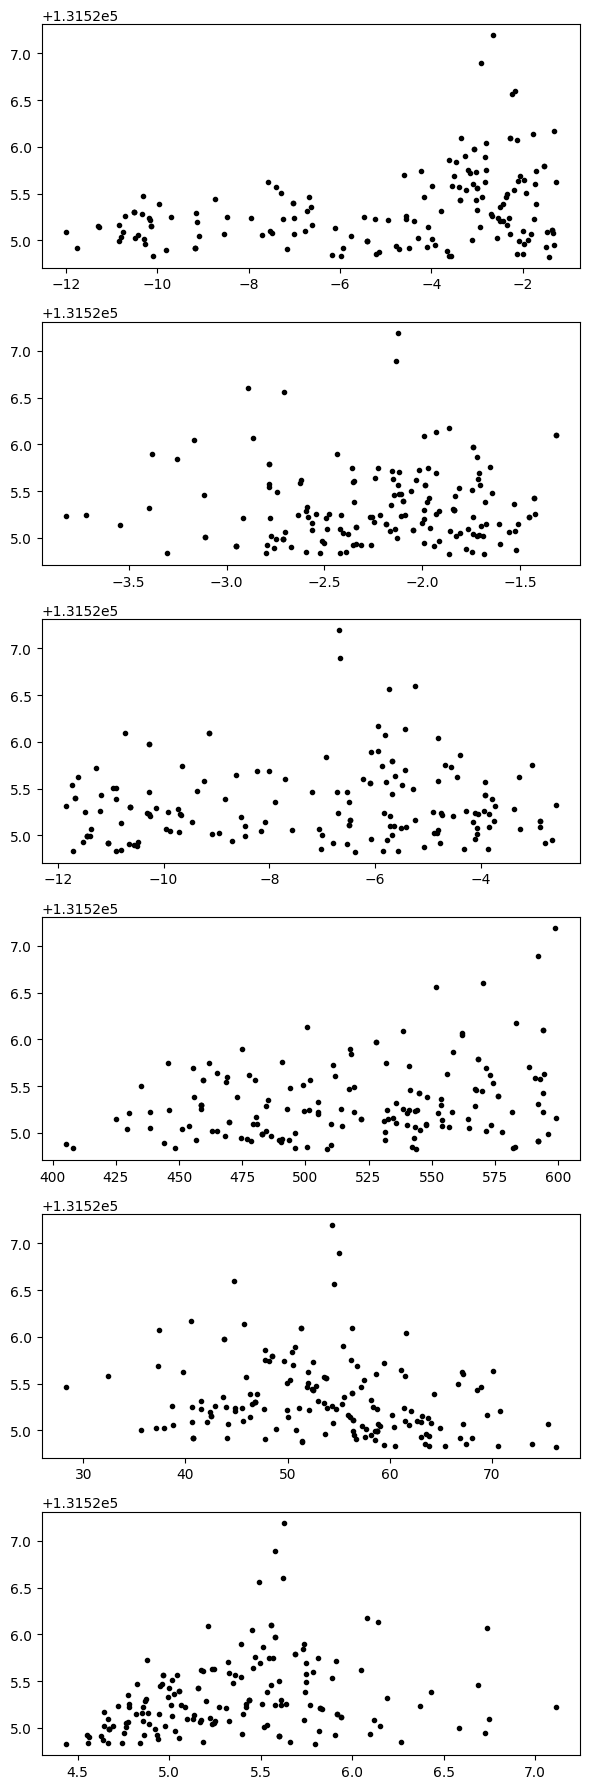

In [18]:
fig, ax = plt.subplots(pos_init.shape[-1], 1, figsize=(6, 3*pos_init.shape[-1]))
# ymin, ymax = (np.quantile(logl_init, 0.5), np.max(logl_init))
# dy = ymax - ymin
# ylim = (ymin - 0.1 * dy, ymax + 0.1 * dy)
for i_param, ax_i in enumerate(ax):
    ax_i.plot(pos_init[:,i_param], logl_init[:], ".k", )
#     ax_i.set_ylim(*ylim)
#     ax_i.set_xlabel(i_param)
#     ax_i.axhline(23374, linestyle=":")
plt.tight_layout()

In [19]:
output = ru.read_walker_prob(walker_path/combined_file_out, tol=8, discard=0)
ord_pos = output[0]
ord_logl = output[1]

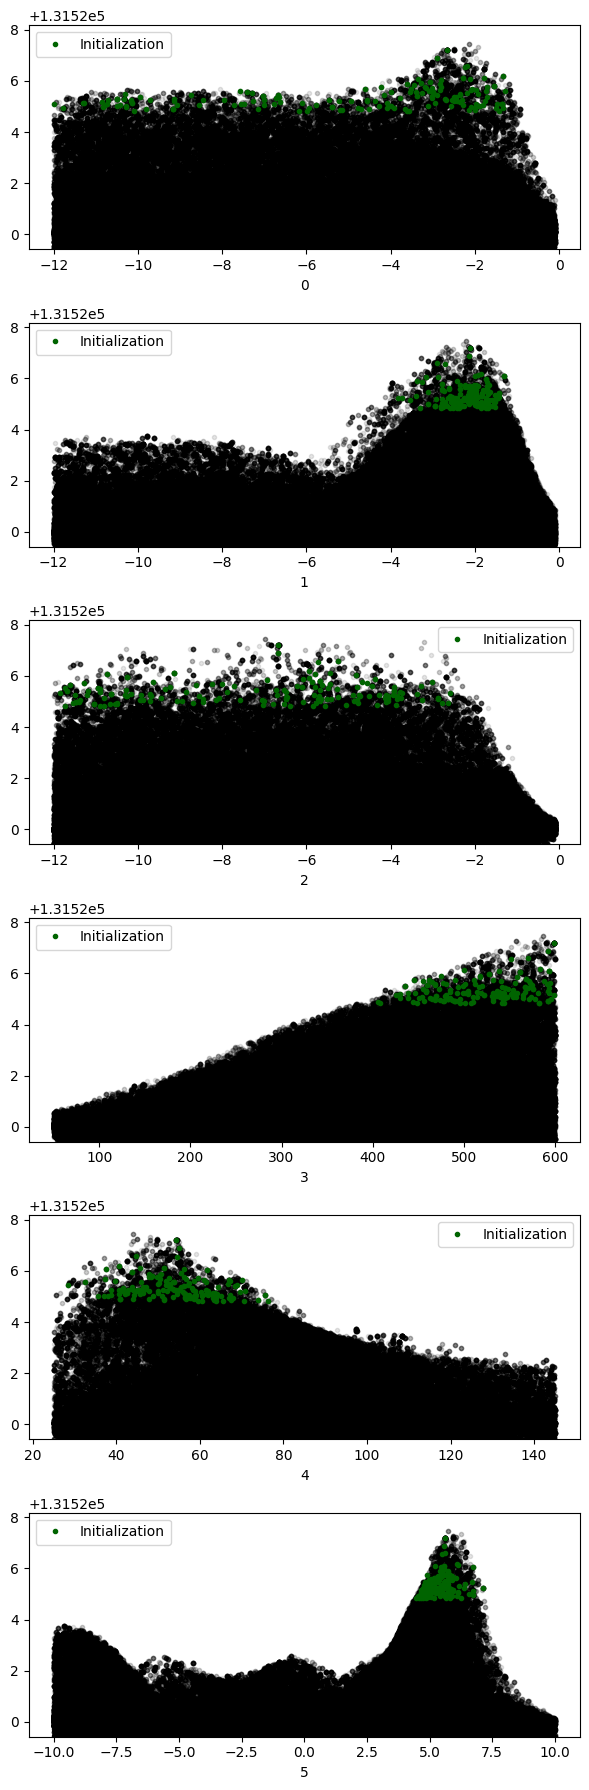

In [20]:
fig, ax = plt.subplots(ord_pos.shape[-1], 1, figsize=(6, 3*ord_pos.shape[-1]))
ymin, ymax = (np.quantile(ord_logl, 0.5), np.max(ord_logl))
dy = ymax - ymin
ylim = (ymin - 0.1 * dy, ymax + 0.1 * dy)
for i_param, ax_i in enumerate(ax):
    ax_i.plot(ord_pos[:,i_param], ord_logl[:], ".k", alpha=0.1)
    ax_i.plot(pos_init[:,i_param], logl_init, ".", color='darkgreen', label='Initialization')
    ax_i.set_ylim(*ylim)
    ax_i.set_xlabel(i_param)
#     ax_i.axhline(23374, linestyle=":")
    ax_i.legend()
plt.tight_layout()